In [1]:
import os

# 先设置 OpenMP 相关环境变量（必须在导入 numpy/torch/torchvision 之前）
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 临时绕过 libomp/libiomp 冲突
os.environ["OMP_NUM_THREADS"] = "1"

import torchvision
import torchvision.transforms as transforms
import numpy as np

def binarize(x):
    return (x > 0.5).float()

transform = transforms.Compose([
    transforms.Resize((10, 10)),
    transforms.ToTensor(),
    #transforms.Lambda(binarize)
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

In [4]:
X = []
y = []

for img, label in dataset:
    X.append(img.numpy())   # (1,10,10)
    y.append(label)

X = np.array(X)  # (N,1,10,10) #第二个维度是通道数，MNIST是单通道图像，所以是1
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (60000, 1, 10, 10)
y shape: (60000,)


In [4]:
print("前5个样本的标签:", y[:5])
print("前5个样本的图像数据（前10个像素）:", X[:5, 0, :10, :10])

前5个样本的标签: [5 0 4 1 9]
前5个样本的图像数据（前10个像素）: [[[0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.01568628 0.05098039 0.10196079
   0.15294118 0.19215687 0.09803922 0.        ]
  [0.         0.         0.11764706 0.52156866 0.7058824  0.7647059
   0.6        0.44313726 0.16862746 0.        ]
  [0.         0.         0.07843138 0.44705883 0.7490196  0.30980393
   0.1764706  0.01568628 0.00392157 0.        ]
  [0.         0.         0.         0.03529412 0.47843137 0.33333334
   0.05098039 0.         0.         0.        ]
  [0.         0.         0.         0.         0.09411765 0.5294118
   0.53333336 0.07450981 0.         0.        ]
  [0.         0.         0.         0.00784314 0.10980392 0.44313726
   0.8        0.18431373 0.         0.        ]
  [0.         0.01176471 0.10588235 0.3647059  0.72156864 0.6901961
   0.32941177 0.03529412 0.         0.        ]
  [0.         0.19607843 0.611764

In [2]:
X1 = []
y1 = []

for img, label in dataset:
    X1.append(img.numpy())   # (1,10,10)
    y1.append(label)
X1 = np.array(X1)  # (N,1,10,10) #第二个维度是通道数，MNIST是单通道图像，所以是1
y1 = np.array(y1)

image=X1[0, 0, :10, :10]

print("X shape:", X1.shape)
print("y shape:", y1.shape)

print("前2个样本的标签:", y1[:2])
print("前2个样本的图像数据（前10个像素）:", X1[:2, 0, :10, :10])

X shape: (60000, 1, 10, 10)
y shape: (60000,)
前2个样本的标签: [5 0]
前2个样本的图像数据（前10个像素）: [[[0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.01568628 0.05098039 0.10196079
   0.15294118 0.19215687 0.09803922 0.        ]
  [0.         0.         0.11764706 0.52156866 0.7058824  0.7647059
   0.6        0.44313726 0.16862746 0.        ]
  [0.         0.         0.07843138 0.44705883 0.7490196  0.30980393
   0.1764706  0.01568628 0.00392157 0.        ]
  [0.         0.         0.         0.03529412 0.47843137 0.33333334
   0.05098039 0.         0.         0.        ]
  [0.         0.         0.         0.         0.09411765 0.5294118
   0.53333336 0.07450981 0.         0.        ]
  [0.         0.         0.         0.00784314 0.10980392 0.44313726
   0.8        0.18431373 0.         0.        ]
  [0.         0.01176471 0.10588235 0.3647059  0.72156864 0.6901961
   0.32941177 0.03529412 0.         0.   

(10, 10)


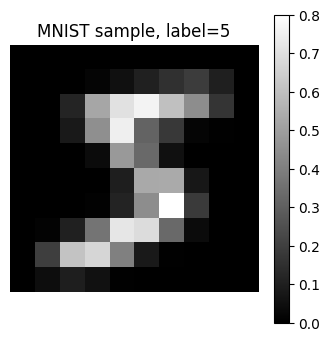

In [6]:
import matplotlib.pyplot as plt

img = X[0, 0]
print(img.shape)  # (10, 10)

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.colorbar()
plt.title(f"MNIST sample, label={y[0]}")
plt.axis("off")
plt.show()